In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
TARGET = "../../data/raw_concat/diabetes.json" # File dữ liệu đã ghép nối lại
INDICATOR_LINKS = "../data/urls/diabetes.txt" # File indicators thô

In [3]:
# Tiến hành đọc dữ liệu
with open(TARGET, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
print(df.describe())

        NumericValue        TimeDim
count  205482.000000  211564.000000
mean       16.649353    2003.465826
std        30.958923      10.682982
min         0.000000    1980.000000
25%         5.778044    1995.000000
50%         9.694469    2004.000000
75%        20.118644    2012.000000
max      1957.000000    2022.000000


In [4]:
# Thử in thử
df.head()

,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode,Date
0,EUR,ESP,18.5 [16.0-20.9],18.5,2002-01-01T00:00:00+01:00,2002-12-31T00:00:00+01:00,2002,YEAR,2002,NCDMORT3070,2024-12-18T14:54:42.07+01:00
1,EUR,DEU,10.1 [8.7-11.6],10.1,2004-01-01T00:00:00+01:00,2004-12-31T00:00:00+01:00,2004,YEAR,2004,NCDMORT3070,2024-12-18T14:54:42.07+01:00
2,EMR,TUN,15.5 [9.6-24.1],15.5,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00,2014,YEAR,2014,NCDMORT3070,2024-12-18T14:54:42.07+01:00
3,EUR,GRC,8.4 [7.2-9.5],8.4,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00,2010,YEAR,2010,NCDMORT3070,2024-12-18T14:54:42.07+01:00
4,AFR,MLI,25.8 [15.3-37.0],25.8,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00,2000,YEAR,2000,NCDMORT3070,2024-12-18T14:54:42.07+01:00


In [5]:
# Chương trình xử lý dữ liệu (chuyển đổi giá trị để tiến hành hiển thị)
df["NumericValue"] = pd.to_numeric(df["NumericValue"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [7]:
def check_null(frame, fields=["ParentLocationCode", "SpatialDim", "Value", "NumericValue", "Date", "IndicatorCode"]):
    for field in fields:
        num = frame[field].isnull().sum()
        print(f"Trường: {field} có {num} giá trị null!")
check_null(df)

Trường: ParentLocationCode có 9570 giá trị null!
Trường: SpatialDim có 0 giá trị null!
Trường: Value có 0 giá trị null!
Trường: NumericValue có 6082 giá trị null!
Trường: Date có 73888 giá trị null!
Trường: IndicatorCode có 0 giá trị null!


In [15]:
# Tiến hành so sánh giá trị NULL và không NULL của bộ dữ liệu
# Cách tổ chức đẹp hơn là việc viết code trên hiển thị từng dòng
df.isna().sum().to_frame('null_count')

,null_count
ParentLocationCode,8481
SpatialDim,0
Dim1,4462
Value,0
NumericValue,6082
Date,73888
IndicatorCode,0


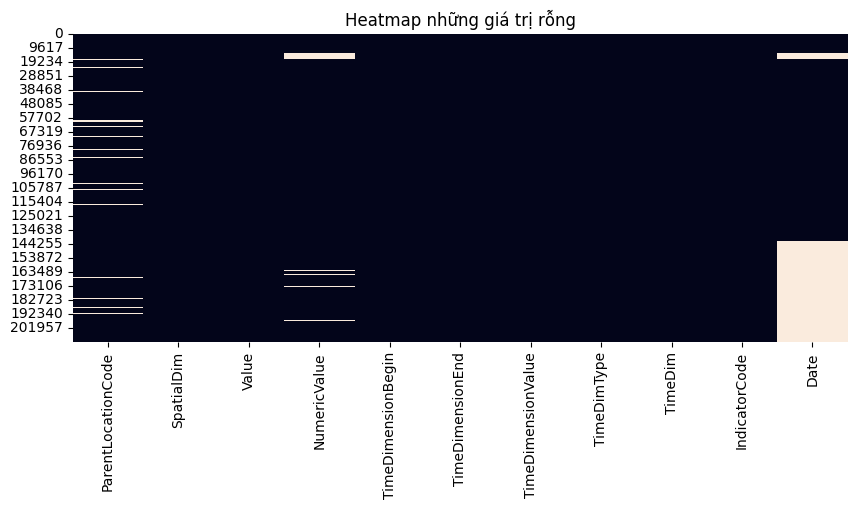

In [8]:
# Tiến hành vẽ hiển thị thử về các giá trị NULL
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Heatmap những giá trị rỗng")
plt.show()

<Axes: >

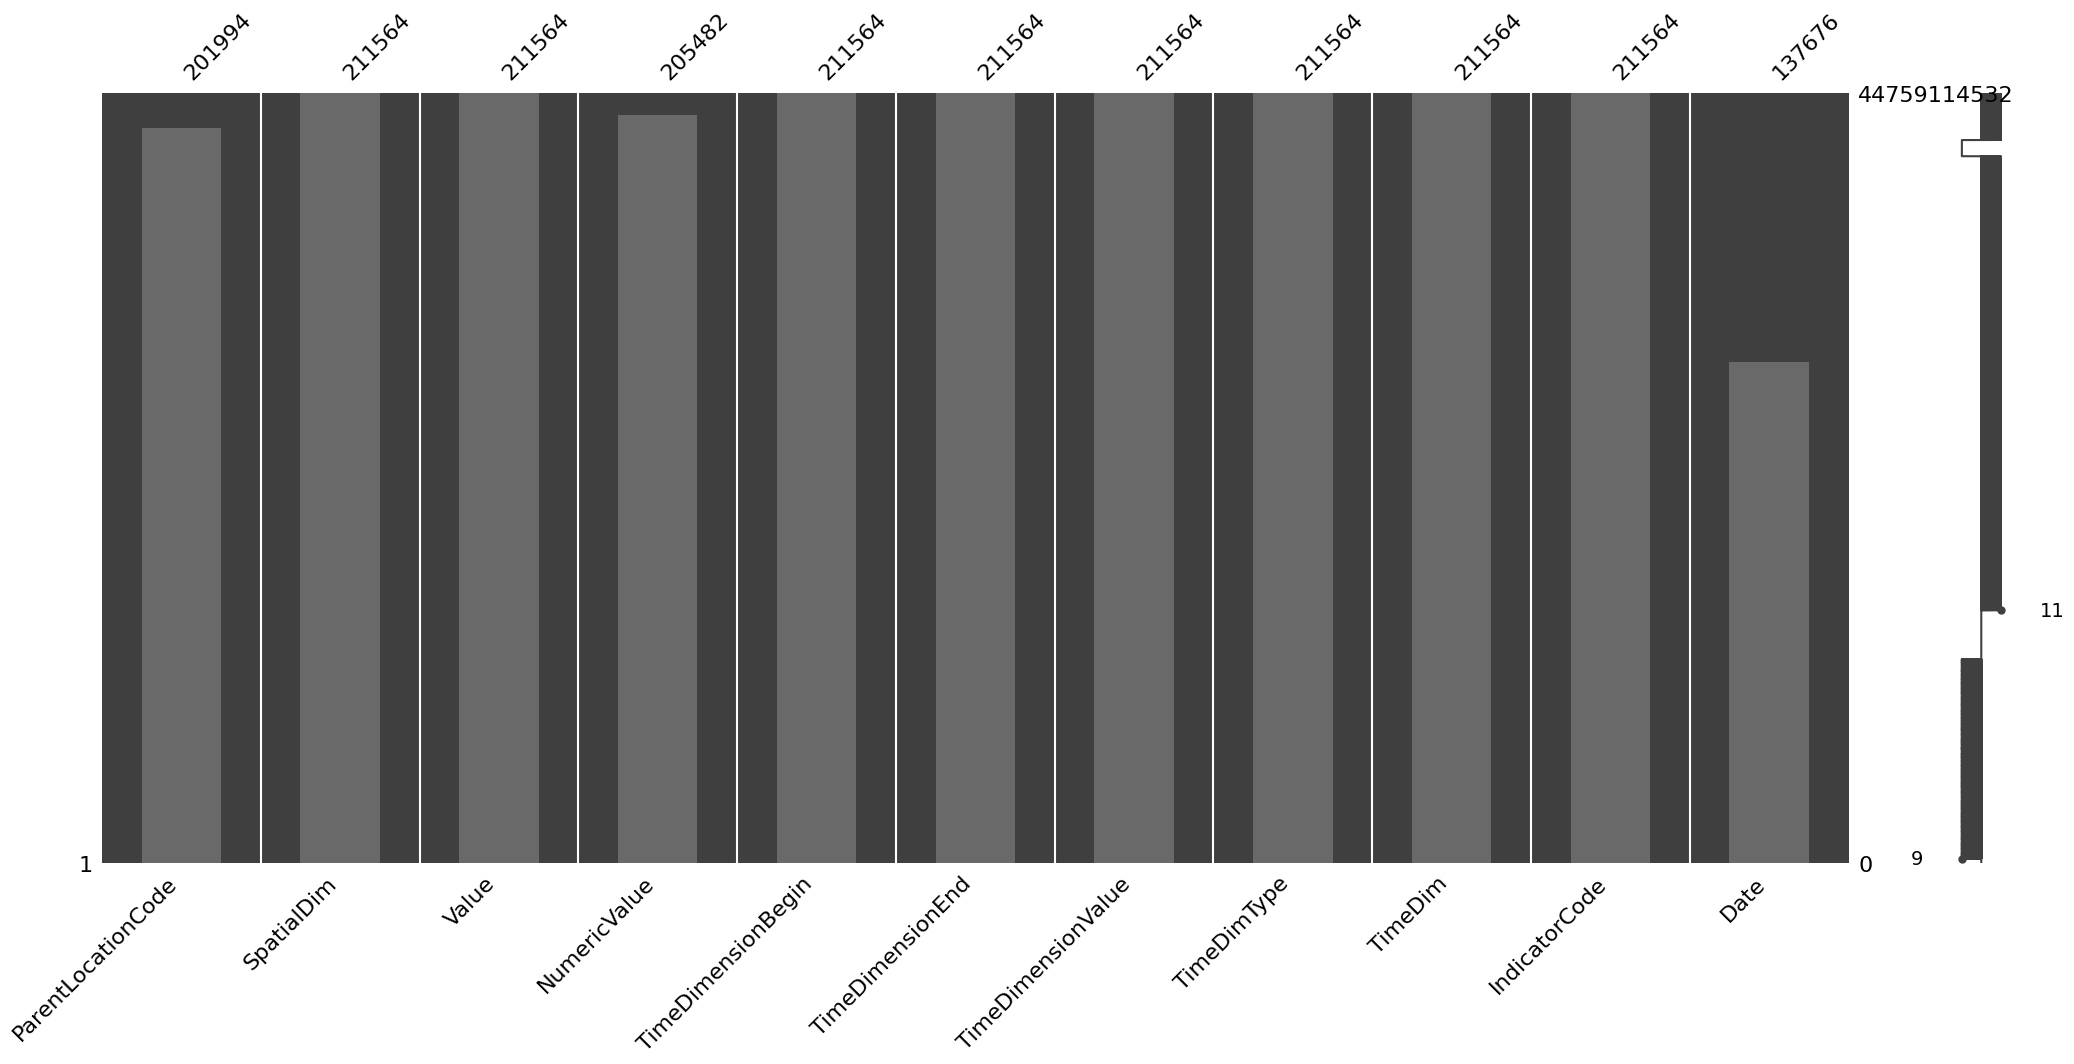

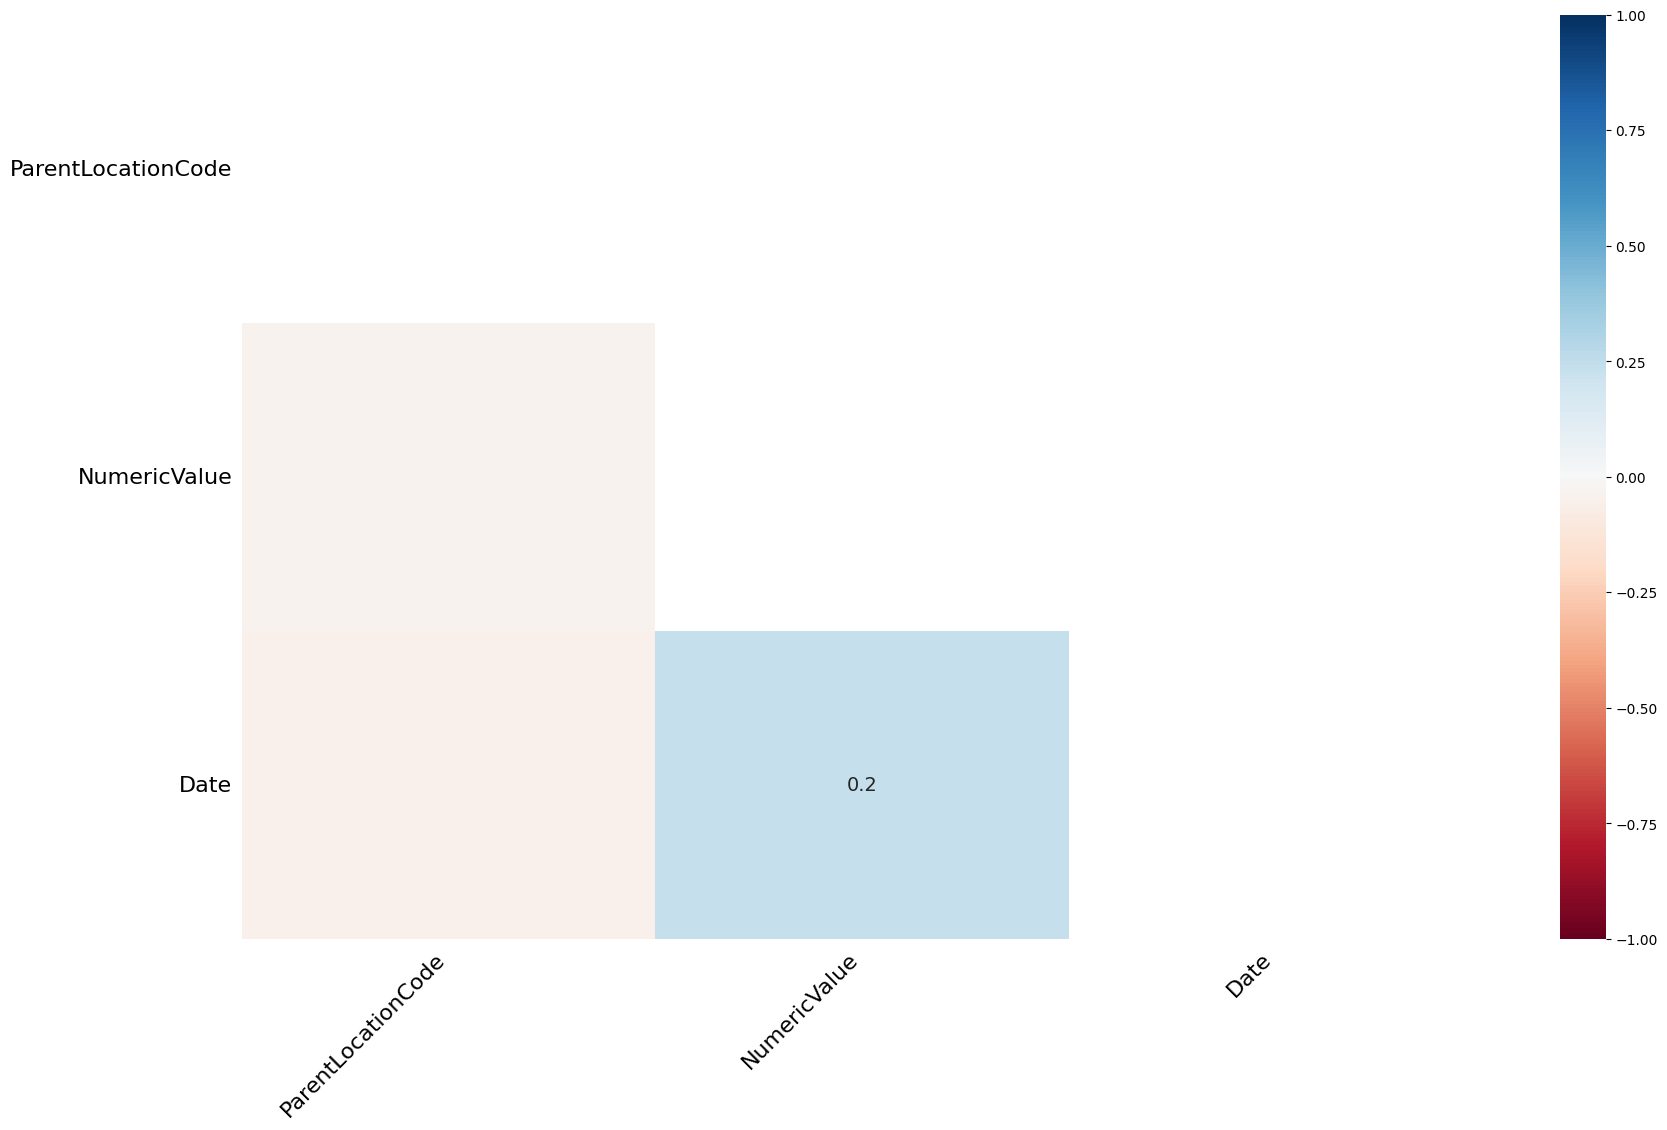

In [9]:
# Sử dụng thư viện bên ngoài để vẽ hiển thị
msno.matrix(df, figsize=(10,4))
msno.bar(df)
msno.heatmap(df)

In [10]:
# Bổ sung thêm cơ sở ra quyết định với loại biểu đồ
df.groupby('Dim1')['NumericValue'].apply(
    lambda x: x.isna().mean()
).sort_values(ascending=False)

KeyError: 'Dim1'

KeyError: 'Country'

In [ ]:
# Tiến hành xem lại đã xử lí OK chưa?
df.isna().sum()

In [4]:
# Tiến hành hiển thị tương quan
df.corr()

ValueError: could not convert string to float: 'SEAR'